In [1]:
import pandas as pd

# Load the new CSV file for the 2023 temperature data
outdoor_temp_df = pd.read_csv('./campaign_data/outdoor_temp.csv')

# Convert 'Date/Time' to datetime format and extract the date
outdoor_temp_df['Date/Time'] = pd.to_datetime(outdoor_temp_df['Date/Time'])
outdoor_temp_df['Date'] = outdoor_temp_df['Date/Time'].dt.date

# Group the data by date and 'sensor_id_outdoor_temp' to find the daily max and min temperatures for each sensor
daily_max_min_per_sensor = outdoor_temp_df.groupby(['Date', 'sensor_id_outdoor_temp'])['Value'].agg(['max', 'min']).reset_index()

# Now, average these daily maximums and minimums across all sensors to obtain single max and min values for each day
average_daily_max_min = daily_max_min_per_sensor.groupby('Date').agg({'max': 'mean', 'min': 'mean'}).reset_index()

average_daily_max_min['Date']  = pd.to_datetime(average_daily_max_min['Date'])
average_daily_max_min.sort_values(by=['Date'], inplace=True)

# Rename columns for clarity in merging
average_daily_max_min.rename(columns={'max': 'campaign_max', 'min': 'campaign_min'}, inplace=True)

# Prepare the data for plotting
min_dates_campaign = average_daily_max_min['Date']
max_dates_campaign = average_daily_max_min['Date']
min_temps_campaign = average_daily_max_min['campaign_min']
max_temps_campaign = average_daily_max_min['campaign_max']


/tmp/ipykernel_17550/2951965569.py:4: DtypeWarning: Columns (7,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  outdoor_temp_df = pd.read_csv('./campaign_data/outdoor_temp.csv')


In [2]:
import pandas as pd

# Load the data
min_temp_df = pd.read_csv('GMET_data/minimum_temperatures_transformed_sorted.csv')
max_temp_df = pd.read_csv('GMET_data/maximum_temperatures_transformed_sorted.csv')

# Convert the 'DATE' column to datetime
min_temp_df['DATE'] = pd.to_datetime(min_temp_df['DATE'])
max_temp_df['DATE'] = pd.to_datetime(max_temp_df['DATE'])

# Prepare the data for future merging
min_temp_df.set_index('DATE', inplace=True)
max_temp_df.set_index('DATE', inplace=True)

# Rename columns for clarity in merging
min_temp_df.rename(columns={'TEMPERATURE': 'GMET_min'}, inplace=True)
max_temp_df.rename(columns={'TEMPERATURE': 'GMET_max'}, inplace=True)

# # Extract the data for the year 2022
# min_temp_2022_df = min_temp_df[min_temp_df.index.year >= 2022]
# max_temp_2022_df = max_temp_df[max_temp_df.index.year >= 2022]


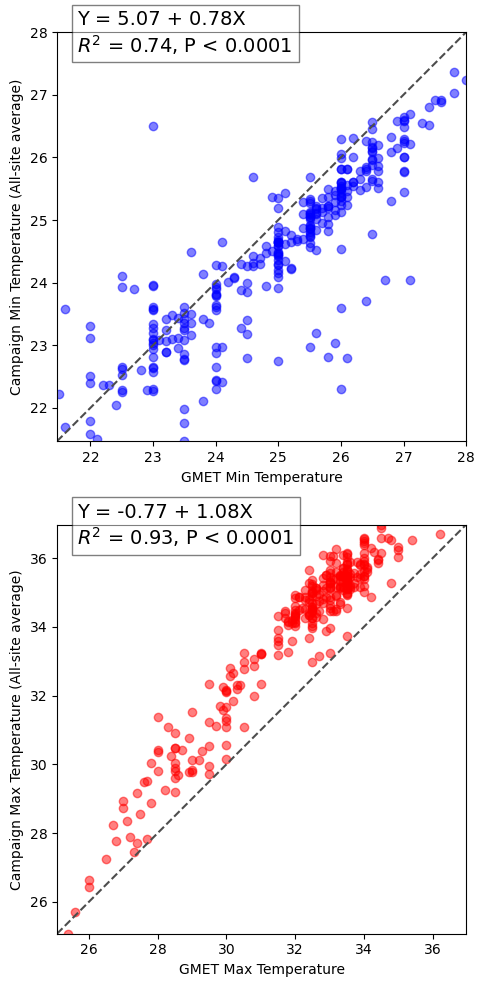

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()

def annotate_fit(x, y, ax):
    x_reset = x.reset_index(drop=True)
    y_reset = y.reset_index(drop=True)

    df = pd.DataFrame({'x': x_reset, 'y': y_reset}).dropna()

    if not df.empty:
        X = sm.add_constant(df['x'])
        model = sm.OLS(df['y'], X).fit()
        a, b = model.params['const'], model.params['x']
        r2 = model.rsquared
        p_value_slope = model.pvalues['x']

        if p_value_slope < 0.0001:
            p_text = "P < 0.0001"
        else:
            p_text = f"P = {p_value_slope:.4f}"

        ax.annotate(f'Y = {a:.2f} + {b:.2f}X\n$R^2$ = {r2:.2f}, {p_text}', 
                    xy=(0.05, 0.95), xycoords='axes fraction', 
                    fontsize=14, bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
    else:
        print("DataFrame created from x and y is empty.")

def find_common_limits(x, y):
    combined = pd.concat([x, y])
    return (combined.min(), combined.max())

# Assuming GMET data and campaign data are already loaded and preprocessed as shown previously
# Merge GMET and campaign data on date index
merged_min_temp = min_temp_df.join(average_daily_max_min.set_index('Date'), how='inner')
merged_max_temp = max_temp_df.join(average_daily_max_min.set_index('Date'), how='inner')

# Filter non-overlapping dates
merged_min_temp.dropna(subset=['campaign_min', 'GMET_min'], inplace=True)
merged_max_temp.dropna(subset=['campaign_max', 'GMET_max'], inplace=True)

# Correlation analysis
plt.figure(figsize=(10, 10))

# Min temperatures
ax_min = plt.subplot(211)
if not merged_min_temp.empty:
    min_limits = find_common_limits(merged_min_temp['GMET_min'], merged_min_temp['campaign_min'])
    ax_min.set_xlim(min_limits)
    ax_min.set_ylim(min_limits)
    ax_min.set_aspect('equal')
    ax_min.plot(min_limits, min_limits, ls="--", c=".3")
    ax_min.scatter(merged_min_temp['GMET_min'], merged_min_temp['campaign_min'], c='blue', alpha=0.5)
    annotate_fit(merged_min_temp['GMET_min'], merged_min_temp['campaign_min'], ax_min)
ax_min.set_xlabel('GMET Min Temperature')
ax_min.set_ylabel('Campaign Min Temperature (All-site average)')

# Max temperatures
ax_max = plt.subplot(212)
if not merged_max_temp.empty:
    max_limits = find_common_limits(merged_max_temp['GMET_max'], merged_max_temp['campaign_max'])
    ax_max.set_xlim(max_limits)
    ax_max.set_ylim(max_limits)
    ax_max.set_aspect('equal')
    # ax_max.axvline(x=35)
    ax_max.plot(max_limits, max_limits, ls="--", c=".3")
    ax_max.scatter(merged_max_temp['GMET_max'], merged_max_temp['campaign_max'], c='red', alpha=0.5)
    annotate_fit(merged_max_temp['GMET_max'], merged_max_temp['campaign_max'], ax_max)
ax_max.set_xlabel('GMET Max Temperature')
ax_max.set_ylabel('Campaign Max Temperature (All-site average)')

plt.tight_layout()
plt.savefig('GMET_campaign_min_max_comparisons.png', bbox_inches='tight')


In [9]:
# Function to calculate the number and fraction of hot days
def calculate_hot_days(df, column, threshold):
    hot_days = df[df[column] > threshold]
    total_days = len(df)
    hot_days_count = len(hot_days)
    hot_days_fraction = hot_days_count / total_days if total_days > 0 else 0
    return hot_days_count, hot_days_fraction

# Calculate the number and fraction of days where max temperature exceeded 35°C
overlapping_max_temp_df = merged_max_temp.dropna(subset=['campaign_max', 'GMET_max'])
met_hot_max_days_count, met_hot_max_days_fraction = calculate_hot_days(overlapping_max_temp_df, 'GMET_max', 35)
campaign_hot_max_days_count, campaign_hot_max_days_fraction = calculate_hot_days(overlapping_max_temp_df, 'campaign_max', 35)

# Calculate the number and fraction of days where min temperature exceeded 30°C
overlapping_min_temp_df = merged_min_temp.dropna(subset=['campaign_min', 'GMET_min'])
met_hot_min_days_count, met_hot_min_days_fraction = calculate_hot_days(overlapping_min_temp_df, 'GMET_min', 30)
campaign_hot_min_days_count, campaign_hot_min_days_fraction = calculate_hot_days(overlapping_min_temp_df, 'campaign_min', 30)

# Print the results
print(f"MET Station Data (Overlapping) - Max Temp > 35°C: {met_hot_max_days_count} days ({met_hot_max_days_fraction:.2%} of overlapping days)")
print(f"Campaign Data (Overlapping) - Max Temp > 35°C: {campaign_hot_max_days_count} days ({campaign_hot_max_days_fraction:.2%} of overlapping days)")

print(f"MET Station Data (Overlapping) - Min Temp > 30°C: {met_hot_min_days_count} days ({met_hot_min_days_fraction:.2%} of overlapping days)")
print(f"Campaign Data (Overlapping) - Min Temp > 30°C: {campaign_hot_min_days_count} days ({campaign_hot_min_days_fraction:.2%} of overlapping days)")


MET Station Data (Overlapping) - Max Temp > 35°C: 2 days (0.66% of overlapping days)
Campaign Data (Overlapping) - Max Temp > 35°C: 129 days (42.72% of overlapping days)
MET Station Data (Overlapping) - Min Temp > 30°C: 0 days (0.00% of overlapping days)
Campaign Data (Overlapping) - Min Temp > 30°C: 0 days (0.00% of overlapping days)


/tmp/ipykernel_17550/969579348.py:10: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  campaign_humidity_df = pd.read_csv('./campaign_data/outdoor_hum.csv')
/tmp/ipykernel_17550/969579348.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gmet_humidity_morning.rename(columns={'HUMIDITY': 'GMET_morning_humidity'}, inplace=True)
/tmp/ipykernel_17550/969579348.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gmet_humidity_afternoon.rename(columns={'HUMIDITY': 'GMET_afternoon_humidity'}, inplace=True)


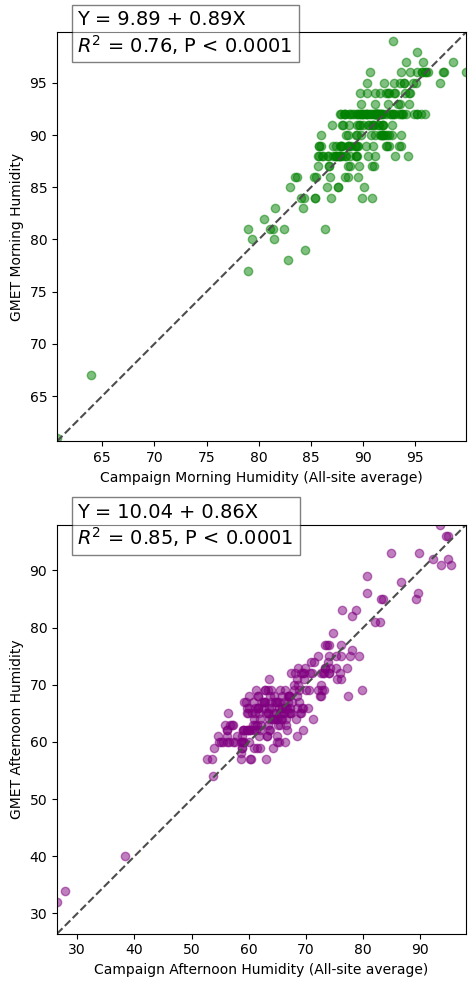

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()

# Load the GMET and campaign humidity data
gmet_humidity_df = pd.read_csv('GMET_data/relative_humidity_transformed_sorted.csv')
campaign_humidity_df = pd.read_csv('./campaign_data/outdoor_hum.csv')

# Convert the datetime information into pandas datetime format
gmet_humidity_df['DATETIME'] = pd.to_datetime(gmet_humidity_df['DATETIME'])
campaign_humidity_df['Date/Time'] = pd.to_datetime(campaign_humidity_df['Date/Time'])

# For the campaign data, calculate the average humidity across all sensors for the timestamps closest to 06:00 and 15:00 each day
campaign_humidity_df['Hour'] = campaign_humidity_df['Date/Time'].dt.hour
morning = campaign_humidity_df[campaign_humidity_df['Hour'] == 6]
afternoon = campaign_humidity_df[campaign_humidity_df['Hour'] == 15]

# Take the average for each sensor closest to 06:00 and 15:00
campaign_humidity_morning_avg = morning.groupby(morning['Date/Time'].dt.date).agg({'Value': 'mean'}).reset_index()
campaign_humidity_afternoon_avg = afternoon.groupby(afternoon['Date/Time'].dt.date).agg({'Value': 'mean'}).reset_index()

# Rename columns for clarity in merging
campaign_humidity_morning_avg.rename(columns={'Value': 'Campaign_morning_humidity', 'Date/Time': 'Date'}, inplace=True)
campaign_humidity_afternoon_avg.rename(columns={'Value': 'Campaign_afternoon_humidity', 'Date/Time': 'Date'}, inplace=True)

# GMET humidity data is already at 06:00 and 15:00, so just extract the date and the value
gmet_humidity_df['Date'] = gmet_humidity_df['DATETIME'].dt.date
gmet_humidity_morning = gmet_humidity_df[gmet_humidity_df['DATETIME'].dt.hour == 6]
gmet_humidity_afternoon = gmet_humidity_df[gmet_humidity_df['DATETIME'].dt.hour == 15]

# Rename columns for clarity in merging
gmet_humidity_morning.rename(columns={'HUMIDITY': 'GMET_morning_humidity'}, inplace=True)
gmet_humidity_afternoon.rename(columns={'HUMIDITY': 'GMET_afternoon_humidity'}, inplace=True)

# Merge the GMET data with campaign averages based on the date
merged_morning = pd.merge(gmet_humidity_morning, campaign_humidity_morning_avg, on='Date', how='inner')
merged_afternoon = pd.merge(gmet_humidity_afternoon, campaign_humidity_afternoon_avg, on='Date', how='inner')

# Function to perform linear regression and plot
def annotate_fit(x, y, ax):
    x_reset = x.reset_index(drop=True)
    y_reset = y.reset_index(drop=True)

    df = pd.DataFrame({'x': x_reset, 'y': y_reset}).dropna()

    if not df.empty:
        X = sm.add_constant(df['x'])
        model = sm.OLS(df['y'], X).fit()
        a, b = model.params['const'], model.params['x']
        r2 = model.rsquared
        p_value_slope = model.pvalues['x']

        if p_value_slope < 0.0001:
            p_text = "P < 0.0001"
        else:
            p_text = f"P = {p_value_slope:.4f}"

        ax.annotate(f'Y = {a:.2f} + {b:.2f}X\n$R^2$ = {r2:.2f}, {p_text}', 
                    xy=(0.05, 0.95), xycoords='axes fraction', 
                    fontsize=14, bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
    else:
        print("DataFrame created from x and y is empty.")

def find_common_limits(x, y):
    combined = pd.concat([x, y])
    return (combined.min(), combined.max())

# Create the plot for the morning and afternoon comparisons
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

# Morning humidity
if not merged_morning.empty:
    morning_limits = find_common_limits(merged_morning['Campaign_morning_humidity'], merged_morning['GMET_morning_humidity'])
    ax[0].set_xlim(morning_limits)
    ax[0].set_ylim(morning_limits)
    ax[0].set_aspect('equal')
    ax[0].plot(morning_limits, morning_limits, ls="--", c=".3")
    ax[0].scatter(merged_morning['Campaign_morning_humidity'], merged_morning['GMET_morning_humidity'], c='green', alpha=0.5)
    annotate_fit(merged_morning['Campaign_morning_humidity'], merged_morning['GMET_morning_humidity'], ax[0])
ax[0].set_xlabel('Campaign Morning Humidity (All-site average)')
ax[0].set_ylabel('GMET Morning Humidity')

# Afternoon humidity
if not merged_afternoon.empty:
    afternoon_limits = find_common_limits(merged_afternoon['Campaign_afternoon_humidity'], merged_afternoon['GMET_afternoon_humidity'])
    ax[1].set_xlim(afternoon_limits)
    ax[1].set_ylim(afternoon_limits)
    ax[1].set_aspect('equal')
    ax[1].plot(afternoon_limits, afternoon_limits, ls="--", c=".3")
    ax[1].scatter(merged_afternoon['Campaign_afternoon_humidity'], merged_afternoon['GMET_afternoon_humidity'], c='purple', alpha=0.5)
    annotate_fit(merged_afternoon['Campaign_afternoon_humidity'], merged_afternoon['GMET_afternoon_humidity'], ax[1])
ax[1].set_xlabel('Campaign Afternoon Humidity (All-site average)')
ax[1].set_ylabel('GMET Afternoon Humidity')

plt.tight_layout()
plt.savefig('GMET_campaign_humidity_comparisons.png', bbox_inches='tight')
plt.show()
